In [1]:
# Paper Link = https://ai2-website.s3.amazonaws.com/publications/CVPR17_TQA.pdf
# Are You Smarter Than A Sixth Grader? Textbook Question Answering for Multimodal Machine Comprehension
from datasets import load_dataset

ds = load_dataset("lmms-lab/GQA", "challenge_balanced_images")

/opt/conda/envs/llava/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating challenge split: 100%|██████████| 1590/1590 [00:00<00:00, 1791.32 examples/s]


In [5]:
ds['challenge']

Dataset({
    features: ['id', 'image'],
    num_rows: 1590
})

In [6]:
from datasets import load_dataset

ds = load_dataset("lmms-lab/GQA", "challenge_all_instructions")
ds

Generating challenge split: 100%|██████████| 713449/713449 [00:00<00:00, 2035518.60 examples/s]


DatasetDict({
    challenge: Dataset({
        features: ['id', 'imageId', 'question', 'isBalanced'],
        num_rows: 713449
    })
})

In [9]:
ds['challenge'][1000]

{'id': '201332165',
 'imageId': 'n358733',
 'question': 'Is the black bag to the right or to the left of the man that is carrying bags?',
 'isBalanced': False}

In [10]:
from datasets import load_dataset

ds = load_dataset("lmms-lab/GQA", "challenge_balanced_images")

In [11]:
ds['challenge']

Dataset({
    features: ['id', 'image'],
    num_rows: 1590
})

In [12]:
from datasets import load_dataset

ds = load_dataset("Ghaser/Wikipedia-Knowledge-2M")

Repo card metadata block was not found. Setting CardData to empty.
Generating train split: 2019163 examples [06:03, 5554.93 examples/s]


In [15]:
ds['train'][0]

{'__key__': 'wikipedia_images_2m/Q12497249',
 '__url__': '/home/ubuntu/.cache/huggingface/datasets/downloads/a095ba81298ceebcad7589a25083f79f93ca4ae01580fb36ec4edabb91dc8f9c',
 'jpg': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=341x256>}

### GQA Dataset Exploration

/home/ubuntu/Multimodal-Uncertainty-Quantification/datasets_/GQA/questions1.2/train_all_questions/train_all_questions_3.json


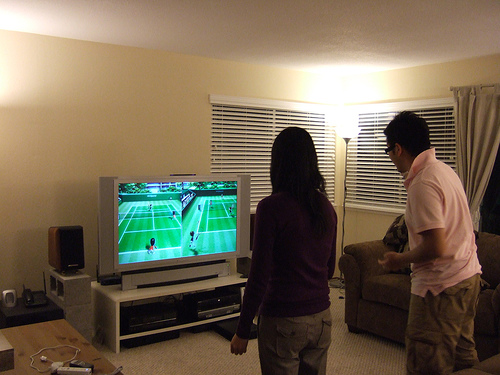

**Question**: Do you see either any towel dispensers or cages?

**Answer**: no

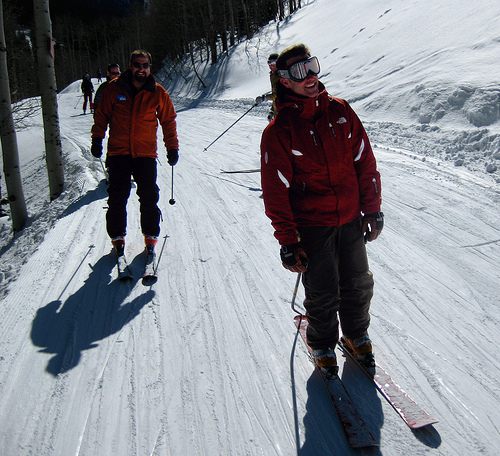

**Question**: Do you see people to the right of the men on the left side?

**Answer**: no

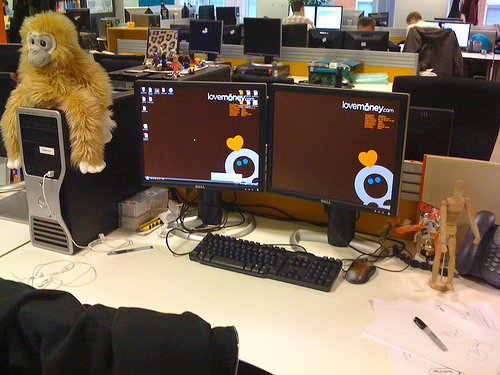

**Question**: Does the device that is to the right of the man seem to be off?

**Answer**: no

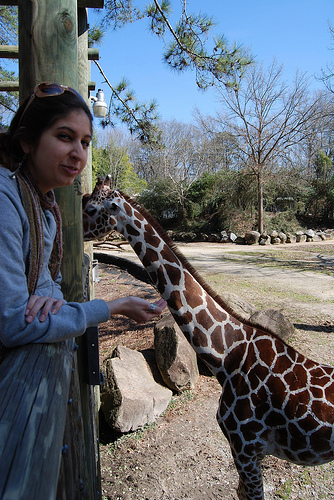

**Question**: Do you see chairs there?

**Answer**: no

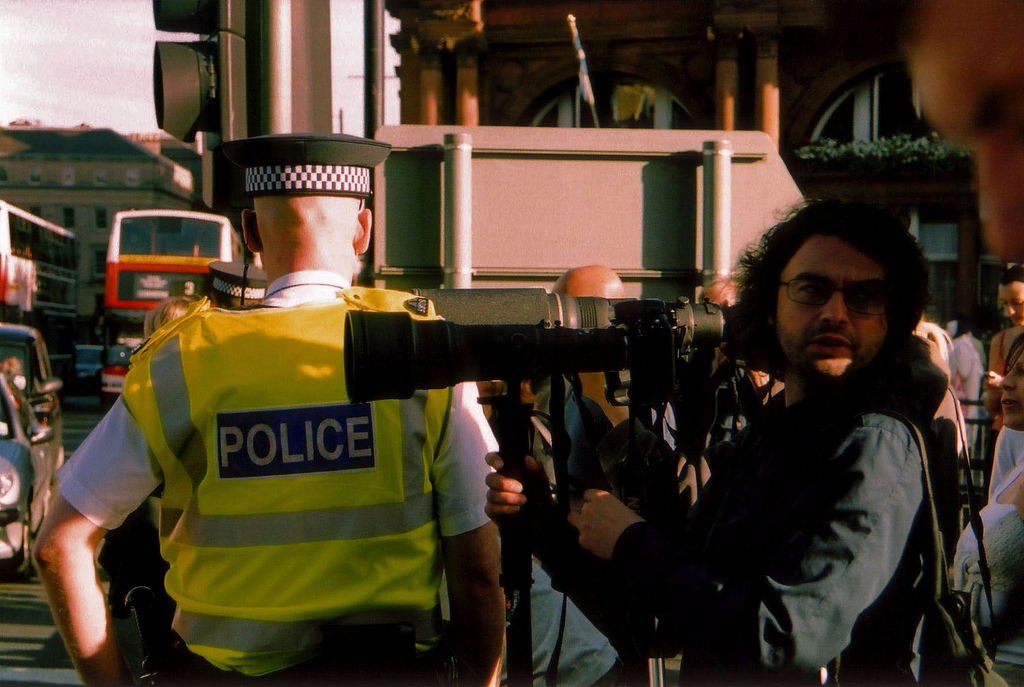

**Question**: Does that bus look red?

**Answer**: yes

In [1]:
import glob
import json
import pickle
import random
from PIL import Image
from IPython.display import display, display_markdown

def get_file_names():
    file_names = glob.glob("/home/ubuntu/Multimodal-Uncertainty-Quantification/datasets_/GQA/questions1.2/train_all_questions/*.json")
    return file_names

def load_json(file_path):
    with open(file_path, "r") as f:
        data = json.load(f)
    return data

def write_pickle(data, filename):
    with open(filename + ".pkl", "wb") as f:
        pickle.dump(data, f)

# Make pickle data file
file_names = get_file_names()
file_names = [file_names[0]]

pickle_list = []

for file_name in file_names:
    print(file_name)
    data = load_json(file_name)

    for line in data:
        pickle_list.append([data[line]["answer"], data[line]["imageId"], data[line]["question"]])
write_pickle(pickle_list, "test")

# Function to load and display images
def display_images_and_questions(samples, image_dir='/home/ubuntu/Multimodal-Uncertainty-Quantification/datasets_/GQA/images/'):
    for sample in samples:
        answer, image_id, question = sample
        image_path = f"{image_dir}{image_id}.jpg"  # Assuming images are in JPG format
        try:
            image = Image.open(image_path)
            display(image)
            display_markdown(f"**Question**: {question}\n\n**Answer**: {answer}", raw=True)
        except Exception as e:
            print(f"Error loading image {image_id}: {e}")

# Randomly sample some images and their questions
num_samples = 5
random_samples = random.sample(pickle_list, num_samples)
display_images_and_questions(random_samples)


In [2]:
import json
import os

# Load the GQA dataset files
def load_gqa_dataset(questions_file, scene_graphs_file):
    with open(questions_file, 'r') as f:
        questions_data = json.load(f)
    
    with open(scene_graphs_file, 'r') as f:
        scene_graphs_data = json.load(f)
    
    return questions_data, scene_graphs_data

# Define the paths to the dataset files
questions_file = '/home/ubuntu/Multimodal-Uncertainty-Quantification/datasets_/GQA/questions1.2/train_all_questions/train_all_questions_0.json'
scene_graphs_file = '/home/ubuntu/Multimodal-Uncertainty-Quantification/datasets_/GQA/sceneGraphs/train_sceneGraphs.json'

# Load the dataset
questions_data, scene_graphs_data = load_gqa_dataset(questions_file, scene_graphs_file)


In [3]:
# how many questions are there in the dataset?
num_questions = len(questions_data)
num_questions

1430536

In [10]:
questions_data

{'07333408': {'semantic': [{'operation': 'select',
    'dependencies': [],
    'argument': 'wall (722332)'},
   {'operation': 'filter color', 'dependencies': [0], 'argument': 'white'},
   {'operation': 'relate', 'dependencies': [1], 'argument': '_,on,s (722335)'},
   {'operation': 'query', 'dependencies': [2], 'argument': 'name'}],
  'entailed': [],
  'equivalent': ['07333408'],
  'question': 'What is on the white wall?',
  'imageId': '2375429',
  'isBalanced': True,
  'groups': {'global': '', 'local': '14-wall_on,s'},
  'answer': 'pipe',
  'semanticStr': 'select: wall (722332)->filter color: white [0]->relate: _,on,s (722335) [1]->query: name [2]',
  'annotations': {'answer': {'0': '722335'},
   'question': {'4:6': '722332'},
   'fullAnswer': {'1': '722335', '5': '722332'}},
  'types': {'detailed': 'relS', 'semantic': 'rel', 'structural': 'query'},
  'fullAnswer': 'The pipe is on the wall.'},
 '07333409': {'semantic': [{'operation': 'select',
    'dependencies': [],
    'argument': 'p

In [12]:
questions_data['2335045']

KeyError: '2335045'

In [7]:
questions_data['07333408']['fullAnswer']

'The pipe is on the wall.'

In [9]:
'07333408' in list(scene_graphs_data.keys())

False

In [8]:
scene_graphs_data['07333408'].keys()

KeyError: '07333408'

In [52]:
objects = {}
for i in scene_graphs_data['2335045a']['objects'].keys():
    print('key',i)
    print('name', scene_graphs_data['2335045']['objects'][i]['name'])
    objects[i] = scene_graphs_data['2335045']['objects'][i]['name']

key 4629541
name table
key 4629543
name tomato sauce
key 4488225
name peppers
key 4637732
name tomato
key 4637739
name painting
key 4637757
name herb
key 4637756
name cheese
key 4637754
name crust
key 4637711
name herb
key 4629532
name pizza
key 4637726
name glass
key 4637724
name liquid
key 4629554
name knife
key 4637802
name leaf
key 4637801
name leaf
key 4629537
name beverage
key 4637708
name herb
key 4637709
name herb
key 4637769
name mozzarella
key 4637767
name decoration
key 4637764
name herb
key 4637762
name herb
key 4637761
name herb
key 4637793
name leaf
key 4637797
name leaf
key 4637794
name leaf
key 4637798
name leaf


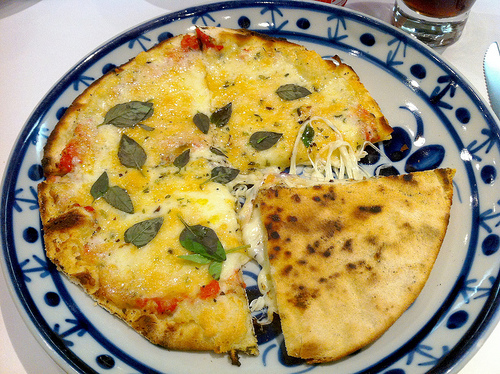

In [13]:
from PIL import Image
from IPython.display import display

#print the image
image_path = '/home/ubuntu/Multimodal-Uncertainty-Quantification/datasets_/GQA/images/2335045.jpg'
image = Image.open(image_path)
display(image)

In [54]:
objects

{'4629541': 'table',
 '4629543': 'tomato sauce',
 '4488225': 'peppers',
 '4637732': 'tomato',
 '4637739': 'painting',
 '4637757': 'herb',
 '4637756': 'cheese',
 '4637754': 'crust',
 '4637711': 'herb',
 '4629532': 'pizza',
 '4637726': 'glass',
 '4637724': 'liquid',
 '4629554': 'knife',
 '4637802': 'leaf',
 '4637801': 'leaf',
 '4629537': 'beverage',
 '4637708': 'herb',
 '4637709': 'herb',
 '4637769': 'mozzarella',
 '4637767': 'decoration',
 '4637764': 'herb',
 '4637762': 'herb',
 '4637761': 'herb',
 '4637793': 'leaf',
 '4637797': 'leaf',
 '4637794': 'leaf',
 '4637798': 'leaf'}

In [53]:
scene_graphs_data['2335045']

{'width': 500,
 'objects': {'4629541': {'name': 'table',
   'h': 372,
   'relations': [],
   'w': 499,
   'attributes': [],
   'y': 0,
   'x': 0},
  '4629543': {'name': 'tomato sauce',
   'h': 38,
   'relations': [{'object': '4629532', 'name': 'on'},
    {'object': '4629532', 'name': 'to the left of'},
    {'object': '4488225', 'name': 'to the left of'},
    {'object': '4637802', 'name': 'to the left of'},
    {'object': '4637762', 'name': 'to the left of'}],
   'w': 27,
   'attributes': [],
   'y': 138,
   'x': 55},
  '4488225': {'name': 'peppers',
   'h': 220,
   'relations': [{'object': '4637761', 'name': 'to the right of'},
    {'object': '4637793', 'name': 'to the left of'},
    {'object': '4637711', 'name': 'to the right of'},
    {'object': '4629543', 'name': 'to the right of'},
    {'object': '4637756', 'name': 'to the left of'},
    {'object': '4637754', 'name': 'to the left of'},
    {'object': '4637794', 'name': 'to the left of'},
    {'object': '4629532', 'name': 'to the le

In [29]:
import matplotlib.pyplot as plt
import networkx as nx
from PIL import Image


def extract_triples(scene_graph):
    triples = set()  # Use a set to store unique triples
        
    # Iterate over each object in the scene graph
    for obj_id, obj_data in scene_graph['objects'].items():
        head_object = obj_data['name']
        
        # Iterate over each relation the object has with other objects
        if len(obj_data['relations']) > 0:
            for relation in obj_data['relations']:
                tail_object_id = relation['object']
                relationship = relation['name']
                # tail_object = object_dict[tail_object_id]
                # Directly access the tail object name without an intermediate dictionary
                tail_object = scene_graph['objects'][tail_object_id]['name']
                triple = (head_object, f'{relationship}', tail_object)
                triples.add(triple)

        if len(obj_data['attributes']) > 0:
            for attribute in obj_data['attributes']:
                tail_object = attribute
                relationship = 'has_attribute'
                triple = (head_object, relationship, tail_object)
                triples.add(triple)
    return triples


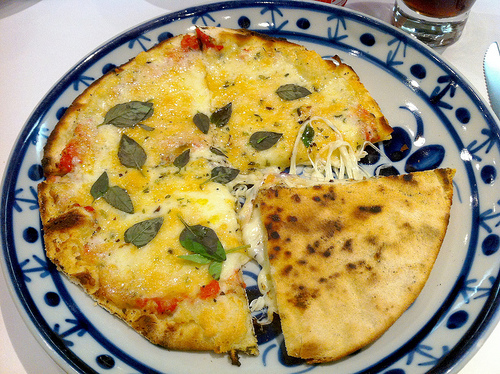

('crust', 'to the right of', 'tomato')
('herb', 'on', 'pizza')
('tomato sauce', 'on', 'pizza')
('peppers', 'to the right of', 'tomato sauce')
('cheese', 'to the right of', 'tomato')
('herb', 'to the left of', 'leaf')
('pizza', 'with', 'cheese')
('liquid', 'has_attribute', 'brown')
('peppers', 'to the left of', 'cheese')
('pizza', 'to the left of', 'knife')
('tomato', 'on', 'pizza')
('pizza', 'to the right of', 'tomato sauce')
('mozzarella', 'to the right of', 'peppers')
('tomato sauce', 'to the left of', 'leaf')
('cheese', 'on', 'pizza')
('crust', 'to the right of', 'herb')
('herb', 'to the left of', 'crust')
('tomato', 'to the left of', 'crust')
('peppers', 'to the right of', 'herb')
('cheese', 'to the right of', 'herb')
('leaf', 'to the right of', 'tomato sauce')
('herb', 'has_attribute', 'green')
('peppers', 'to the left of', 'leaf')
('crust', 'to the right of', 'peppers')
('herb', 'has_attribute', 'fresh')
('herb', 'to the left of', 'pizza')
('peppers', 'to the left of', 'mozzarell

In [30]:
image_id = '2335045'
image_path = f'/home/ubuntu/Multimodal-Uncertainty-Quantification/datasets_/GQA/images/{image_id}.jpg'
image = Image.open(image_path)
display(image)

scene_graph = scene_graphs_data[image_id]
triples = extract_triples(scene_graph)

for triple in triples:
    print(triple)


In [26]:
len(triples)

68

### Check Triple Similarity


In [13]:
from sentence_transformers import SentenceTransformer, util
import numpy as np
import time

# Load pre-trained Sentence-BERT model
model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

# def preprocess_triple(triple):
#     """Normalize the triple by converting to lowercase and joining the elements into a single string."""
#     return ' '.join(word.lower() for word in triple)

# def calculate_similarity(triple1, triple2):
#     """Calculate the semantic similarity between two triples using SBERT embeddings."""
#     embedding1 = model.encode(triple1, convert_to_tensor=True)
#     embedding2 = model.encode(triple2, convert_to_tensor=True)
#     similarity = util.pytorch_cos_sim(embedding1, embedding2)
#     return similarity.item()

# def compare_triple_sets(triples_set1, triples_set2, threshold=0.8):
#     """Compare two sets of triples and count how many are semantically similar."""
#     count = 0
    
#     triples_set1 = list(triples_set1)
#     triples_set2 = list(triples_set2)
    
#     similarity_matrix = np.zeros((len(triples_set1), len(triples_set2)))
#     for triple1_i in range(len(triples_set1)):
#         for triple2_j in range(len(triples_set2)):
#             triple1_str = preprocess_triple(triples_set1[triple1_i])
#             triple2_str = preprocess_triple(triples_set2[triple2_j])
            
#             if similarity_matrix[triple1_i, triple2_j] != 0:
#                 similarity = similarity_matrix[triple1_i, triple2_j]
#             else:
#                 similarity = calculate_similarity(triple1_str, triple2_str)
#                 similarity_matrix[triple1_i, triple2_j] = similarity
#                 if similarity >= threshold:
#                     count += 1
    
#     return count, similarity_matrix

"""
Doing the same thing as above but using the SentenceTransformer's batch encoding feature to speed up the process.
"""
def preprocess_triple(triple):
    """Normalize the triple by converting to lowercase and joining the elements into a single string."""
    return ' '.join(word.lower() for word in triple)

def compare_triple_sets(triples_set1, triples_set2, threshold=0.8):
    """Compare two sets of triples and count how many are semantically similar."""
    
    # Preprocess triples and convert to strings
    triples_set1 = [preprocess_triple(triple) for triple in triples_set1]
    triples_set2 = [preprocess_triple(triple) for triple in triples_set2]
    
    # Encode all triples in both sets at once (batch encoding)
    embeddings1 = model.encode(triples_set1, convert_to_tensor=True)
    embeddings2 = model.encode(triples_set2, convert_to_tensor=True)
    
    # Compute similarity matrix using vectorized operations
    similarity_matrix = util.pytorch_cos_sim(embeddings1, embeddings2).cpu().numpy()
    
    # Count the number of pairs that have a similarity above the threshold
    similar_count = np.sum(similarity_matrix >= threshold)
    
    return similar_count, similarity_matrix

# Example sets of triples
triples_set1 = {
    ('man', 'to the left of', 'dog'),
    ('cat', 'sitting on', 'mat'),
    ('boy', 'playing with', 'ball')   
}

triples_set2 = {
    ('person', 'beside', 'dog'),
    ('cat', 'on', 'carpet'),
    ('child', 'playing with', 'ball')
}

t1 = time.time()
# Compare the two sets
similar_count, similarity_matrix = compare_triple_sets(triples_set1, triples_set2, threshold=0.8)
t2 = time.time()
print(f"Number of semantically similar triples: {similar_count}")
print(f"Time taken: {t2-t1:.2f} seconds")


/opt/conda/envs/llava/lib/python3.10/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Number of semantically similar triples: 1
Time taken: 0.01 seconds


In [14]:
similarity_matrix

array([[ 0.07174506,  0.00887441,  0.65156406],
       [ 0.08249015,  0.9060349 ,  0.12073891],
       [ 0.68623424, -0.01561328,  0.08843452]], dtype=float32)

In [31]:
from sentence_transformers import SentenceTransformer, util
import numpy as np

# Load pre-trained Sentence-BERT model
model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

def preprocess_triple(triple):
    """Normalize the triple by converting to lowercase and joining the elements into a single string."""
    return ' '.join(word.lower() for word in triple)

def calculate_confidence_metric(ground_truth_set, output_set, k=3):
    """Calculate the confidence metric based on the top-K similarities between two sets of triples."""
    
    # Preprocess triples and convert to strings
    ground_truth_list = [preprocess_triple(triple) for triple in ground_truth_set]
    output_list = [preprocess_triple(triple) for triple in output_set]
    
    # Batch encode all triples in both sets
    embeddings_gt = model.encode(ground_truth_list, convert_to_tensor=True)
    embeddings_out = model.encode(output_list, convert_to_tensor=True)
    
    # Compute the cosine similarity matrix in a vectorized manner
    similarity_matrix = util.pytorch_cos_sim(embeddings_gt, embeddings_out).cpu().numpy()
    
    # Flatten the matrix and sort similarities in descending order
    sorted_similarities = np.sort(similarity_matrix.flatten())[::-1]
    
    print('sorted_similarities', sorted_similarities)
    # Take the top-K similarities
    top_k_similarities = sorted_similarities[:k]
    
    # Calculate the confidence metric as the average of the top-K similarities
    confidence_metric = np.mean(top_k_similarities)
    
    return confidence_metric

# Gt Triples and Output Triples when they are completely different
ground_truth_triples = {
    ('dog', 'chasing', 'cat'),
    ('car', 'parked beside', 'tree'),
    ('bird', 'flying over', 'house')
}
# Output Triples
output_triples = {
    ('fish', 'swimming in', 'pond'),
    ('man', 'standing near', 'bicycle'),
    ('apple', 'on', 'table')
}

# # Gt Triples and Output Triples when they are somewhat similar
# ground_truth_triples = {
#     ('cat', 'sitting on', 'mat'),
#     ('boy', 'holding', 'ball'),
#     ('car', 'parked beside', 'tree')
# }

# output_triples = {
#     ('cat', 'lying on', 'rug'),  # Similar but different
#     ('child', 'playing with', 'ball'),  # Similar but different
#     ('vehicle', 'next to', 'bush')  # Similar conceptually but different objects
# }

# # ground_truth_triples = # Ground Truth Triples
# ground_truth_triples = {
#     ('dog', 'barking at', 'stranger'),
#     ('cat', 'sleeping on', 'couch'),
#     ('child', 'holding', 'toy')
# }

# # Output Triples
# output_triples = {
#     ('dog', 'barking at', 'stranger'),
#     ('cat', 'sleeping on', 'couch'),
#     ('child', 'holding', 'toy')
# }

# Calculate the confidence metric
confidence = calculate_confidence_metric(ground_truth_triples, output_triples, k= len(ground_truth_triples))
print(f"Confidence Metric: {confidence}")

sorted_similarities [ 0.18133065  0.15815423  0.09094799  0.06426916  0.01291846 -0.01256428
 -0.01338548 -0.01416769 -0.05096964]
Confidence Metric: 0.14347761869430542


In [59]:
## Dataset statistics
train_questions_path = '/home/ubuntu/Multimodal-Uncertainty-Quantification/datasets_/GQA/questions1.2/train_all_questions/*.json'

def load_json(file_path):
    with open(file_path, "r") as f:
        data = json.load(f)
    return data

def get_dataset_statistics(questions_path):
    file_names = glob.glob(questions_path)
    num_questions = 0
    
    for file_name in file_names:
        data = load_json(file_name)
        num_questions = num_questions + len(data)
        print(f"Number of questions in {file_name}: {len(data)}")
        
    print(f"Total number of questions: {num_questions}")

In [60]:
import glob

get_dataset_statistics(train_questions_path)

Number of questions in /home/ubuntu/Multimodal-Uncertainty-Quantification/datasets_/GQA/questions1.2/train_all_questions/train_all_questions_3.json: 1430536
Number of questions in /home/ubuntu/Multimodal-Uncertainty-Quantification/datasets_/GQA/questions1.2/train_all_questions/train_all_questions_4.json: 1430536


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f56f05d4280>>
Traceback (most recent call last):
  File "/opt/conda/envs/llava/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


Number of questions in /home/ubuntu/Multimodal-Uncertainty-Quantification/datasets_/GQA/questions1.2/train_all_questions/train_all_questions_6.json: 1430536
Number of questions in /home/ubuntu/Multimodal-Uncertainty-Quantification/datasets_/GQA/questions1.2/train_all_questions/train_all_questions_1.json: 1430536
Number of questions in /home/ubuntu/Multimodal-Uncertainty-Quantification/datasets_/GQA/questions1.2/train_all_questions/train_all_questions_0.json: 1430536


In [7]:
import pickle
with open('/home/ubuntu/Multimodal-Uncertainty-Quantification/runs/llava_gqa_temp1_topp1_dp_1000.pkl', 'rb') as f:
    responses = pickle.load(f)

In [1]:
import json
with open("/home/ubuntu/Multimodal-Uncertainty-Quantification/datasets_/GQA/questions1.2/train_all_questions/train_all_questions_0.json") as file:
    questions = json.load(file)

In [4]:
questions['07421524']

{'semantic': [{'operation': 'select',
   'dependencies': [],
   'argument': 'bus (4580990)'},
  {'operation': 'exist', 'dependencies': [0], 'argument': '?'},
  {'operation': 'select', 'dependencies': [], 'argument': 'trains (-) '},
  {'operation': 'exist', 'dependencies': [2], 'argument': '?'},
  {'operation': 'or', 'dependencies': [1, 3], 'argument': ''}],
 'entailed': [],
 'equivalent': ['07421524'],
 'question': 'Do you see either a bus or a train in the picture?',
 'imageId': '1159364',
 'isBalanced': False,
 'groups': {'global': None, 'local': '09existOr-bus_trains'},
 'answer': 'yes',
 'semanticStr': 'select: bus (4580990)->exist: ? [0]->select: trains (-) ->exist: ? [2]->or:  [1, 3]',
 'annotations': {'answer': {},
  'question': {'5': '4580990'},
  'fullAnswer': {'4': '4580990'}},
 'types': {'detailed': 'existOr', 'semantic': 'obj', 'structural': 'logical'},
 'fullAnswer': 'Yes, there is a bus.'}

In [8]:
responses['07421524']

{'responses': [{'answer': 'yes',
   'explanation': 'A red city bus is visible in the picture, which serves as a form of public transit.',
   'confidence': 1},
  {'answer': 'Yes',
   'explanation': "Both a bus and a truck are visible in the picture, with the truck's presence indicated by its crane.",
   'confidence': 1},
  {'answer': 'yes',
   'explanation': 'A large bus is driving on a road alongside a semi, with other vehicles like cars also present in the image.',
   'confidence': 0.95},
  {'answer': 'yes',
   'explanation': 'There is one bus and one train in the picture.',
   'confidence': 1},
  {'answer': 'yes',
   'explanation': 'There is a red city bus and a blue tow truck in the picture, along with some construction equipment.',
   'confidence': 0.98},
  {'answer': 'bus',
   'explanation': 'The image shows a red bus in the foreground driving down a street with traffic behind it. There is no train visible.',
   'confidence': 0.9},
  {'answer': 'yes',
   'explanation': "The street

In [9]:
import pickle

with open('/home/ubuntu/Multimodal-Uncertainty-Quantification/runs/llava_gqa_llama3_sg_grounding_temp_1_topp_1_dp_1000.pkl_1159364.pkl', 'rb') as f:
    results = pickle.load(f)

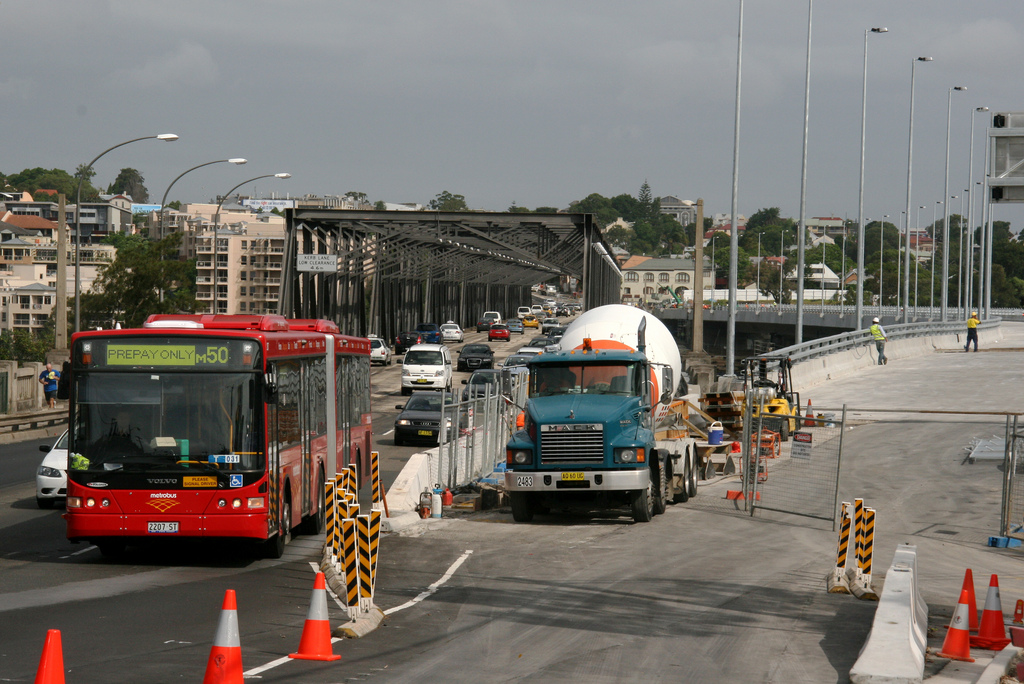

In [10]:
from PIL import Image
image_id = '1159364'
image_path = f'/home/ubuntu/Multimodal-Uncertainty-Quantification/datasets_/GQA/images/{image_id}.jpg'
Image.open(image_path)


In [33]:
results

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18])

In [32]:
results[0].keys()

{0: {'llama3_response_graph': 'Here is the output for the given text:\n\n{\n    "entities": [\n        {"type": "whole", "name": "city bus"},\n        {"type": "whole", "name": "picture"}\n    ],\n    "attributes": [\n        {"type": "color", "entity": "city bus", "value": "red"},\n        {"type": "state", "entity": "picture", "value": "visible"},\n        {"type": "function", "entity": "picture", "value": "serves as a form of public transit"}\n    ],\n    "relations": [\n        {"type": "spatial", "entity1": "city bus", "entity2": "picture", "description": "in"}\n    ]\n}\n\nNote: I assumed that "picture" is a whole entity, as it is a visual representation. If you want to consider it as a part of something else, please let me know.',
  'response_triples': [('city bus', 'is_a', 'whole entity'),
   ('picture', 'is_a', 'whole entity'),
   ('city bus', 'color', 'red'),
   ('picture', 'state', 'visible'),
   ('picture', 'function', 'serves as a form of public transit'),
   ('city bus', 

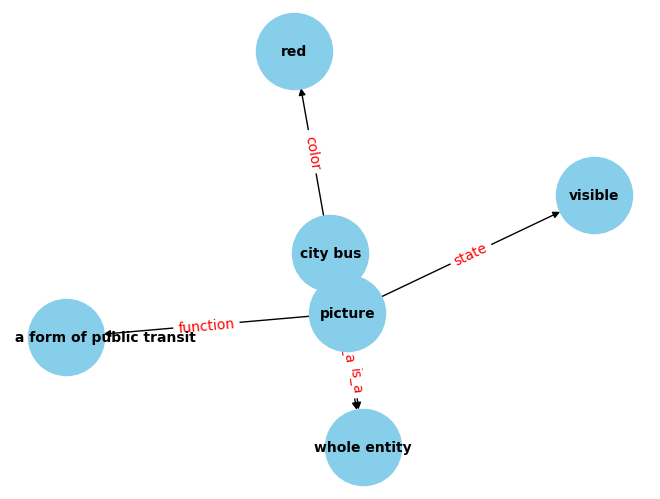

In [26]:
tuples = results[0]['response_triples']

import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add edges to the graph
for subject, predicate, obj in tuples:
    G.add_edge(subject, obj, label=predicate)

# Draw the graph
pos = nx.spring_layout(G)  # Layout for visualization
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="skyblue", font_size=10, font_weight="bold", arrows=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

# Show the graph
plt.show()

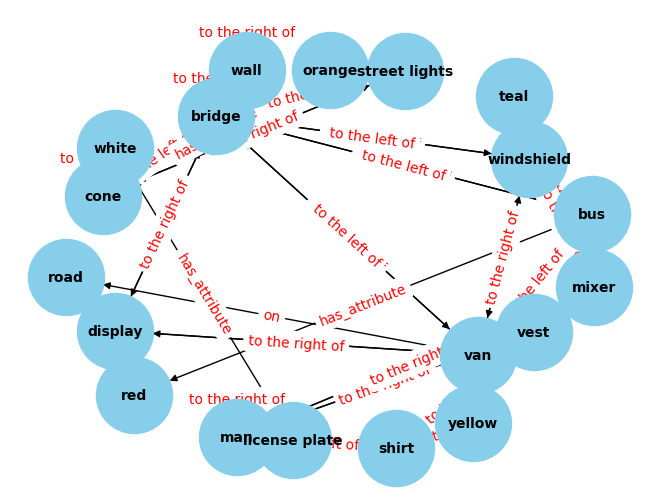

In [31]:
tuples = results[0]['scene_graph_triples']


# Create a directed graph
G = nx.DiGraph()

# Add edges to the graph
for subject, predicate, obj in tuples:
    G.add_edge(subject, obj, label=predicate)

# Draw the graph
pos = nx.spring_layout(G, k=2.5, iterations=50)  # Layout for visualization
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="skyblue", font_size=10, font_weight="bold", arrows=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

# Show the graph
plt.show()

In [ ]:
results[0]

In [26]:
results[0]['scene_graph_triples']

{('boots', 'has_attribute', 'black'),
 ('boots', 'to the left of', 'man'),
 ('boots', 'to the left of', 'rug'),
 ('boots', 'to the left of', 'woman'),
 ('controller', 'has_attribute', 'white'),
 ('controller', 'to the left of', 'shirt'),
 ('controller', 'to the right of', 'people'),
 ('feet', 'has_attribute', 'bare'),
 ('feet', 'to the left of', 'jeans'),
 ('feet', 'to the left of', 'pants'),
 ('feet', 'to the right of', 'people'),
 ('glasses', 'has_attribute', 'black'),
 ('glasses', 'has_attribute', 'clear'),
 ('glasses', 'to the left of', 'hair'),
 ('glasses', 'to the left of', 'man'),
 ('glasses', 'to the left of', 'shirt'),
 ('glasses', 'to the left of', 'woman'),
 ('glasses', 'to the right of', 'people'),
 ('hair', 'has_attribute', 'black'),
 ('hair', 'has_attribute', 'long'),
 ('hair', 'to the left of', 'hair'),
 ('hair', 'to the right of', 'glasses'),
 ('hair', 'to the right of', 'hair'),
 ('hair', 'to the right of', 'people'),
 ('hair', 'to the right of', 'shirt'),
 ('hair', 't

In [21]:
similarity_matrix = np.array(results[0]['similarity_matrix'])

In [22]:
import numpy as np

k = len(results[0]['response_triples'])
sorted_similarities = np.sort(similarity_matrix.flatten())[::-1]
top_k_similarities = sorted_similarities[:k]
confidence_metric = np.mean(top_k_similarities)

In [23]:
confidence_metric

0.6367745

### Plot for all 20 responses

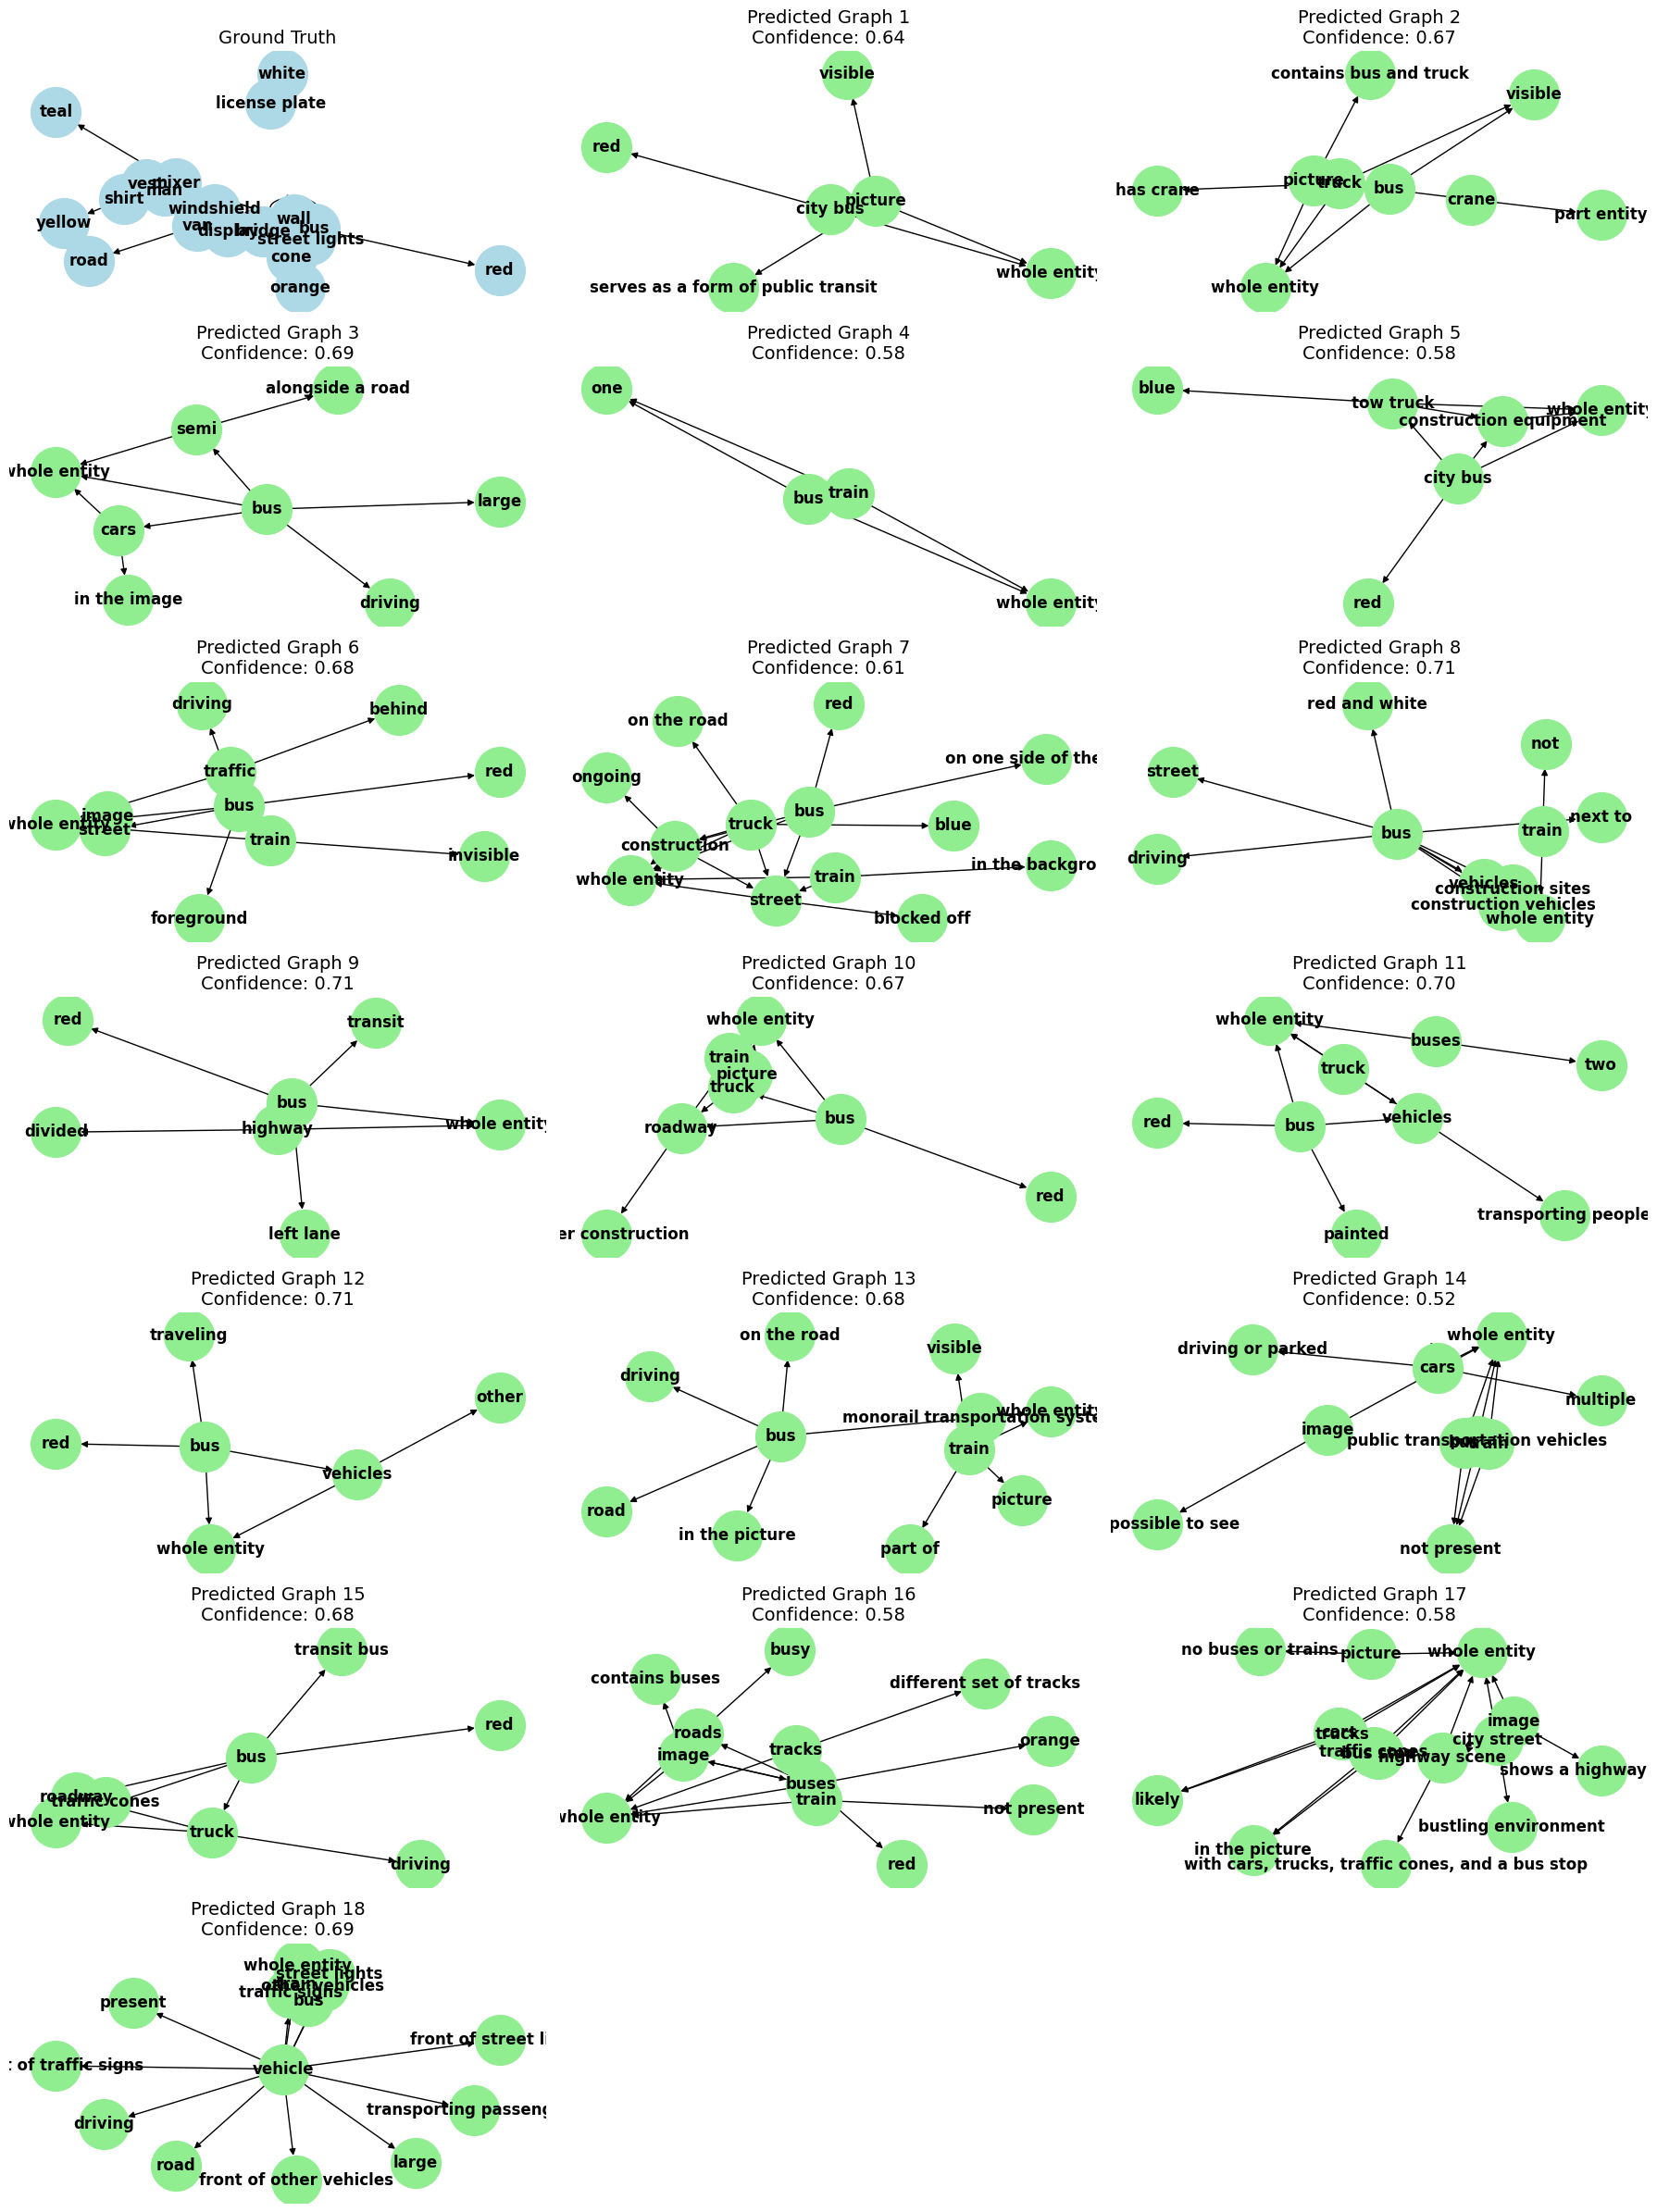

In [39]:
n_graphs = len(results)  # Number of predicted graphs
ground_truth_triples = results[0]['scene_graph_triples']  # Ground truth is the same for all

# Create ground truth graph
ground_truth_graph = nx.DiGraph()
for subject, predicate, obj in ground_truth_triples:
    ground_truth_graph.add_edge(subject, obj, label=predicate)

# Initialize lists to store predicted graphs and confidence metrics
predicted_graphs = []
confidence_metrics = []

# Loop through each predicted graph in 'results'
for i in list(results.keys()):
    predicted_triples = results[i]['response_triples']
    
    # Create a graph for each prediction
    G = nx.DiGraph()
    for subject, predicate, obj in predicted_triples:
        G.add_edge(subject, obj, label=predicate)
    predicted_graphs.append(G)
    
    # Calculate confidence metric
    similarity_matrix = np.array(results[i]['similarity_matrix'])
    k = len(predicted_triples)
    sorted_similarities = np.sort(similarity_matrix.flatten())[::-1]
    top_k_similarities = sorted_similarities[:k]
    confidence_metric = np.mean(top_k_similarities)
    confidence_metrics.append(confidence_metric)

# Determine the number of rows and columns for subplots
n_cols = 3  # Reduce the number of columns
n_rows = int(np.ceil((n_graphs + 1) / n_cols))

# Create the subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 24))  # Increase figure size for larger graphs

# Flatten axes array for easy indexing
axes = axes.flatten()

# Plot the ground truth graph in the first subplot
nx.draw(ground_truth_graph, ax=axes[0], with_labels=True, node_size=1500, node_color="lightblue", font_size=12, font_weight="bold")
axes[0].set_title(f"Ground Truth", fontsize=14)

# Plot the predicted graphs with confidence scores
for i, (G, confidence) in enumerate(zip(predicted_graphs, confidence_metrics)):
    ax = axes[i + 1]
    nx.draw(G, ax=ax, with_labels=True, node_size=1500, node_color="lightgreen", font_size=12, font_weight="bold")
    ax.set_title(f"Predicted Graph {i + 1}\nConfidence: {confidence:.2f}", fontsize=14)

# Remove any unused subplots (in case of fewer graphs)
for j in range(len(predicted_graphs) + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()